# Indian Road Accident Analysis
**Dataset:** `indian_roads_dataset.csv` — 20,000 accident records across 8 major Indian cities

---
## Table of Contents
1. [Data Understanding & Cleaning](#data-cleaning)
2. [Exploratory Data Analysis](#eda)
3. [Accident Severity Prediction](#prediction)
4. [Interactive Widget – Severity Estimator](#widget)

<a id='data-cleaning'></a>
## 1. Data Understanding & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── aesthetic defaults ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

### 1.1 Load Dataset

In [2]:
df = pd.read_csv('indian_roads_dataset.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 20,000 rows × 24 columns


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,22-10-2023,05:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,21-05-2023,04:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,10-07-2024,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,30-03-2025,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,25-01-2024,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


### 1.2 Inspect Rows, Columns and Data Types

In [3]:
print('─── Column Info ───────────────────────────────────────────')
df.info()
print('\n─── Descriptive Statistics (numeric) ─────────────────────')
df.describe()

─── Column Info ───────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperatur

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [4]:
print('─── Descriptive Statistics (categorical) ──────────────────')
df.describe(include='object')

─── Descriptive Statistics (categorical) ──────────────────


,city,state,date,time,day_of_week,road_type,weather,visibility,traffic_density,cause,accident_severity,festival
count,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000,115
unique,8,7,1201,24,7,3,3,3,3,5,3,4
top,Chandigarh,Maharashtra,03-11-2022,02:00,Monday,urban,clear,low,low,distraction,minor,Holi
freq,2577,5009,30,888,2966,6745,6690,9987,7067,4026,11025,38


### 1.4 Check Duplicates

In [5]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'  → Dropped. New shape: {df.shape}')
else:
    print('✅  No duplicate rows found.')

Duplicate rows: 0
✅  No duplicate rows found.


### 1.5 Convert Date to datetime

In [6]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

print('Date column dtype:', df['date'].dtype)
print('Date range:', df['date'].min().date(), '→', df['date'].max().date())
df[['date', 'year', 'month']].head()

Date column dtype: datetime64[ns]
Date range: 2022-01-01 → 2025-04-15


,date,year,month
0,2023-10-22,2023,10
1,2023-05-21,2023,5
2,2024-07-10,2024,7
3,2025-03-30,2025,3
4,2024-01-25,2024,1


<a id='eda'></a>
## 2. Exploratory Data Analysis

### 2.1 Accident Severity Distribution

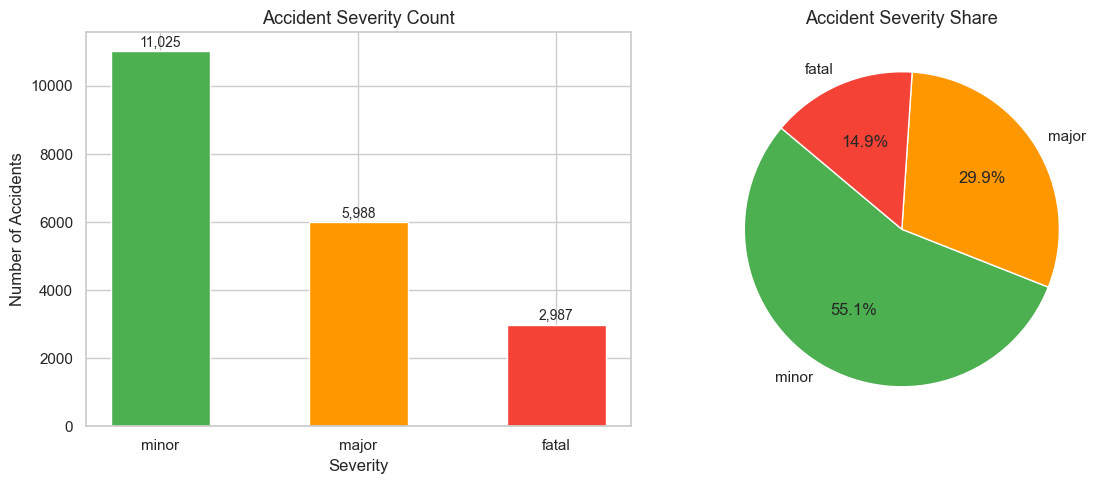

                   count  percent
accident_severity                
minor              11025    55.12
major               5988    29.94
fatal               2987    14.94


In [7]:
sev_order = ['minor', 'major', 'fatal']
sev_colors = {'minor': '#4caf50', 'major': '#ff9800', 'fatal': '#f44336'}

sev_counts = df['accident_severity'].value_counts().reindex(sev_order)
sev_pct    = sev_counts / sev_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(sev_order, sev_counts, color=[sev_colors[s] for s in sev_order], edgecolor='white', width=0.5)
for bar, val in zip(bars, sev_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Accident Severity Count')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Number of Accidents')

# Pie chart
axes[1].pie(sev_counts, labels=sev_order, autopct='%1.1f%%',
            colors=[sev_colors[s] for s in sev_order], startangle=140,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Accident Severity Share')

plt.tight_layout()
plt.show()
print(sev_counts.to_frame('count').assign(percent=sev_pct.round(2)))

##### Insight : The dataset shows a reasonably balanced distribution across severity levels, with minor accidents being the most frequent, followed by major and fatal.

### 2.2 Accidents by City and State

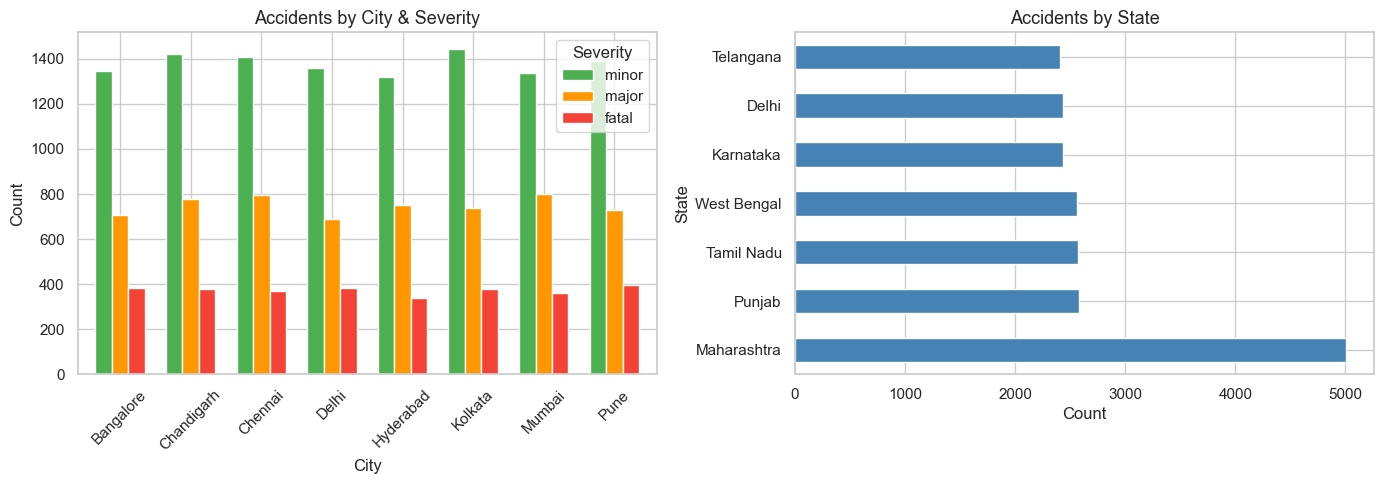

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

city_sev = df.groupby(['city', 'accident_severity']).size().unstack(fill_value=0)[sev_order]
city_sev.plot(kind='bar', ax=axes[0], color=[sev_colors[s] for s in sev_order],
              edgecolor='white', width=0.7)
axes[0].set_title('Accidents by City & Severity')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Count')
axes[0].legend(title='Severity')
axes[0].tick_params(axis='x', rotation=45)

state_counts = df['state'].value_counts()
state_counts.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Accidents by State')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('State')

plt.tight_layout()
plt.show()

##### Insight : Grouped bar charts reveal that larger metropolitan areas (Mumbai, Delhi, Bangalore) report the highest absolute accident volumes. 

### 2.3 Accidents by Hour and Day of Week

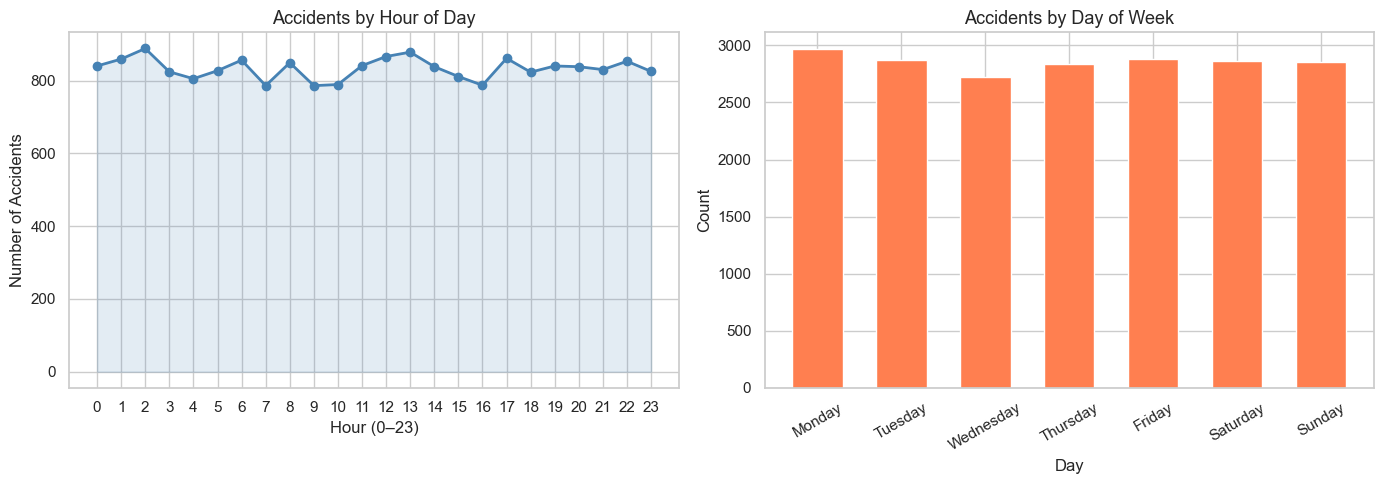

In [9]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly
hour_counts = df.groupby('hour').size()
axes[0].plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, color='steelblue')
axes[0].fill_between(hour_counts.index, hour_counts.values, alpha=0.15, color='steelblue')
axes[0].set_title('Accidents by Hour of Day')
axes[0].set_xlabel('Hour (0–23)')
axes[0].set_ylabel('Number of Accidents')
axes[0].set_xticks(range(0, 24))

# Day of week
dow_counts = df['day_of_week'].value_counts().reindex(day_order)
axes[1].bar(dow_counts.index, dow_counts.values, color='coral', edgecolor='white', width=0.6)
axes[1].set_title('Accidents by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.4 Peak vs Non-Peak Hours

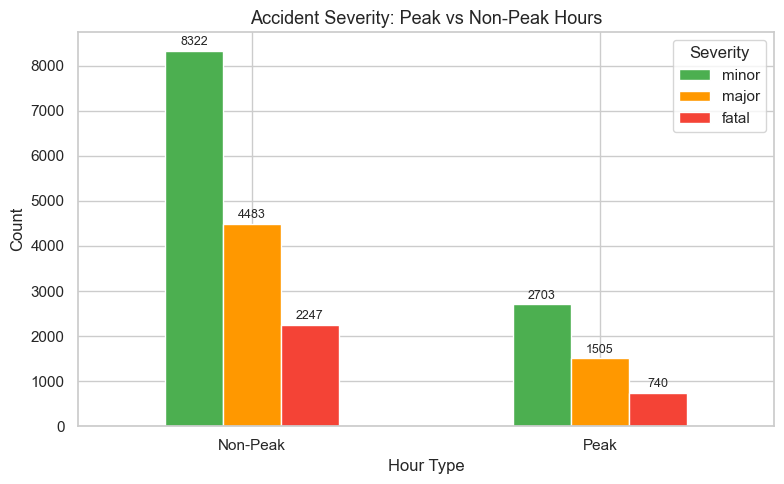


Fatal rate — Peak: 15.0%  | Non-Peak: 14.9%


In [10]:
peak_sev = df.groupby(['is_peak_hour', 'accident_severity']).size().unstack(fill_value=0)[sev_order]
peak_sev.index = ['Non-Peak', 'Peak']

ax = peak_sev.plot(kind='bar', color=[sev_colors[s] for s in sev_order],
                   edgecolor='white', figsize=(8, 5), width=0.5)
ax.set_title('Accident Severity: Peak vs Non-Peak Hours')
ax.set_xlabel('Hour Type')
ax.set_ylabel('Count')
ax.legend(title='Severity')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2, fontsize=9)

plt.tight_layout()
plt.show()

print('\nFatal rate — Peak:',
      f"{peak_sev.loc['Peak', 'fatal'] / peak_sev.loc['Peak'].sum() * 100:.1f}%",
      ' | Non-Peak:',
      f"{peak_sev.loc['Non-Peak', 'fatal'] / peak_sev.loc['Non-Peak'].sum() * 100:.1f}%")

##### Insight : Non-peak hours, particularly late night, show a disproportionately higher share of fatal accidents — likely attributable to higher speeds and reduced visibility.

### 2.5 Weather vs Accident Severity

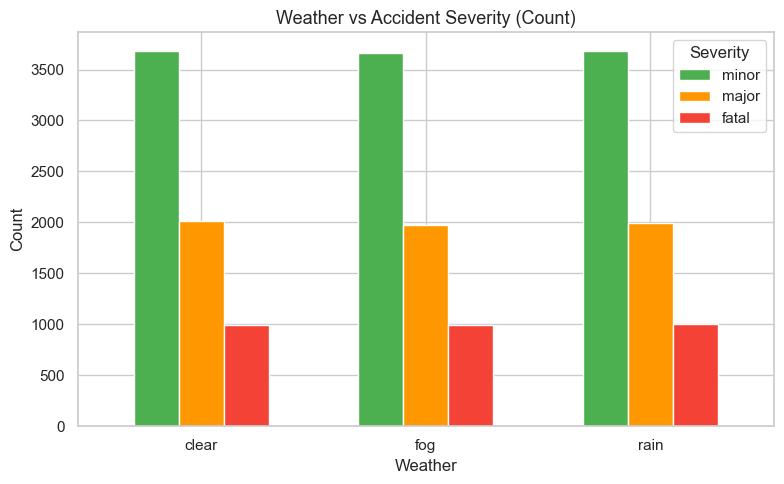

In [11]:
weather_sev = df.groupby(['weather', 'accident_severity']).size().unstack(fill_value=0)[sev_order]

fig, ax = plt.subplots(figsize=(8, 5))

weather_sev.plot(kind='bar', ax=ax, color=[sev_colors[s] for s in sev_order],
                 edgecolor='white', width=0.6)
ax.set_title('Weather vs Accident Severity (Count)')
ax.set_xlabel('Weather')
ax.set_ylabel('Count')
ax.legend(title='Severity')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

##### Insight : Rainy weather elevates major accident frequency. Highway roads carry a significantly higher fatal proportion than urban or rural roads.

### 2.6 Road Type vs Accident Severity

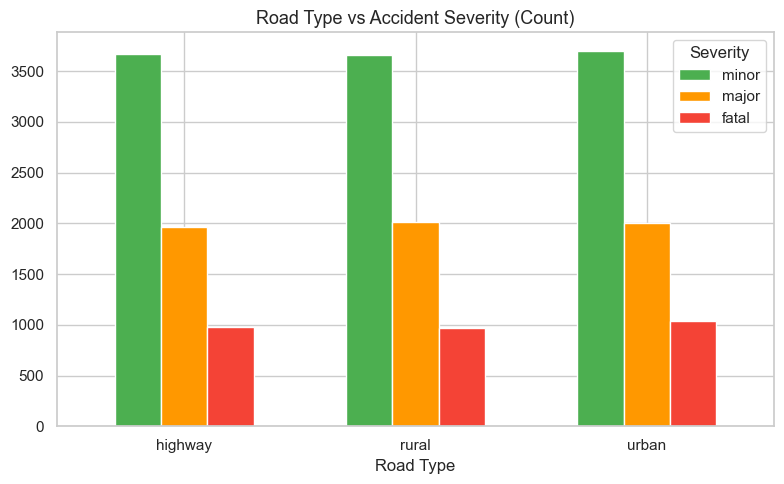

In [12]:
road_sev = df.groupby(['road_type', 'accident_severity']).size().unstack(fill_value=0)[sev_order]

fig, ax = plt.subplots(figsize=(8, 5))

road_sev.plot(kind='bar', ax=ax, color=[sev_colors[s] for s in sev_order],
              edgecolor='white', width=0.6)
ax.set_title('Road Type vs Accident Severity (Count)')
ax.tick_params(axis='x', rotation=0)
ax.set_xlabel('Road Type')
ax.legend(title='Severity')

plt.tight_layout()
plt.show()

### 2.7 Traffic Density vs Severity

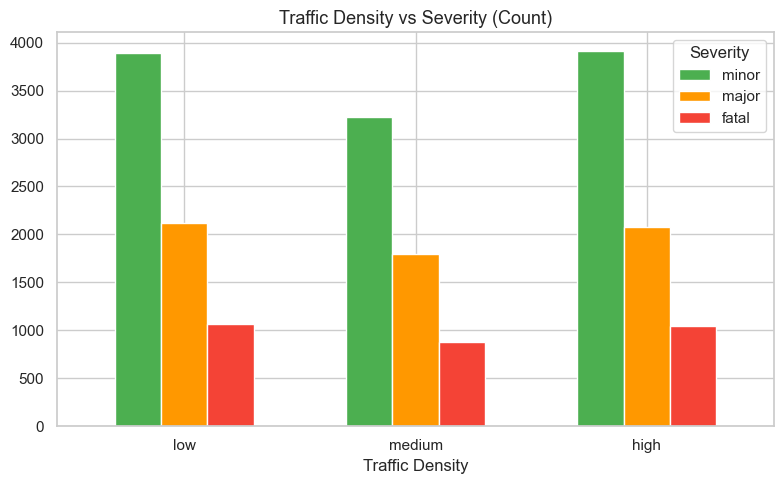

In [13]:
td_order = ['low', 'medium', 'high']
td_sev = df.groupby(['traffic_density', 'accident_severity']).size().unstack(fill_value=0).reindex(td_order)[sev_order]

fig, ax = plt.subplots(figsize=(8, 5))

td_sev.plot(kind='bar', ax=ax, color=[sev_colors[s] for s in sev_order],
            edgecolor='white', width=0.6)
ax.set_title('Traffic Density vs Severity (Count)')
ax.tick_params(axis='x', rotation=0)
ax.set_xlabel('Traffic Density')
ax.legend(title='Severity')

plt.tight_layout()
plt.show()

##### Insight : High traffic density raises the probability of major and fatal outcomes compared to low-density conditions.

### 2.8 Vehicles Involved vs Casualties

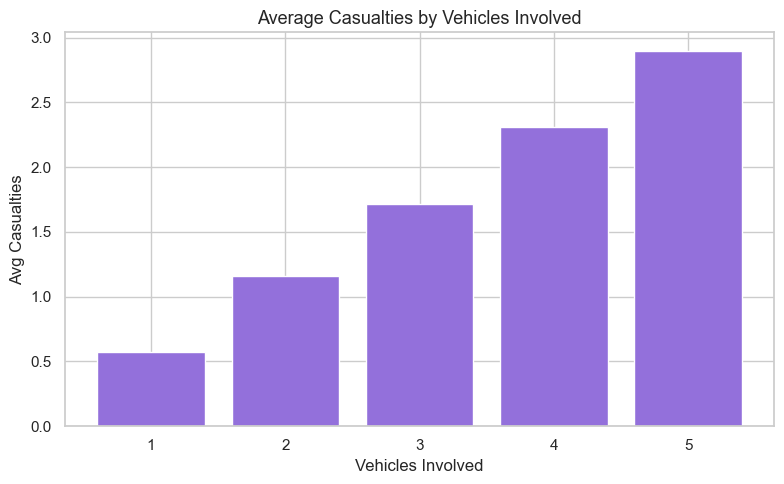

Correlation (vehicles_involved vs casualties): 0.551


In [14]:
# Average casualties per vehicle count
avg_cas = df.groupby('vehicles_involved')['casualties'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(avg_cas.index, avg_cas.values, color='mediumpurple', edgecolor='white')
ax.set_title('Average Casualties by Vehicles Involved')
ax.set_xlabel('Vehicles Involved')
ax.set_ylabel('Avg Casualties')

plt.tight_layout()
plt.show()

print('Correlation (vehicles_involved vs casualties):',
      df[['vehicles_involved', 'casualties']].corr().iloc[0, 1].round(3))

##### Insight: There is a positive correlation between vehicles involved and casualty count. Accidents involving five or more vehicles record the highest average casualties.

### 2.9 Accident Heatmap (Hour × Day)

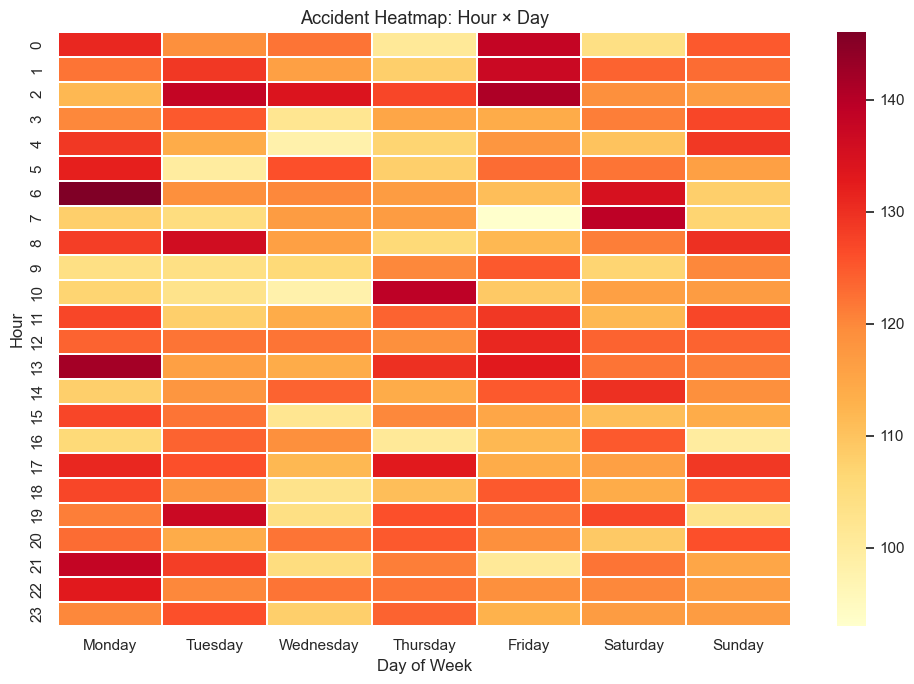

In [15]:
heatmap_data = df.groupby(['hour', 'day_of_week']).size().unstack(fill_value=0).reindex(columns=day_order)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, ax=ax, cmap='YlOrRd', linewidths=0.3, linecolor='white')
ax.set_title('Accident Heatmap: Hour × Day')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour')

plt.tight_layout()
plt.show()

##### Insight : A heatmap of hour versus day of week confirms that weekday mornings carry the highest accident density

<a id='prediction'></a>
## 3. Accident Severity Prediction

### 3.1 Feature Engineering & Encoding

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
from imblearn.over_sampling import SMOTE

# ── Select features ─────────────────────────────────────────────────────────
# cause (accident cause type) adds signal without data leakage
features = ['city', 'weather', 'road_type', 'traffic_density', 'visibility',
            'lanes', 'vehicles_involved', 'hour', 'is_peak_hour', 'is_weekend',
            'cause']
target   = 'accident_severity'

model_df = df[features + [target]].copy()

# ── Label-encode categorical columns ────────────────────────────────────────
cat_cols = ['city', 'weather', 'road_type', 'traffic_density', 'visibility', 'cause']
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    le_dict[col]  = le

# Target encoding
le_target = LabelEncoder()
model_df[target] = le_target.fit_transform(model_df[target])

print('Classes:', le_target.classes_)
print('Encoded as:', list(range(len(le_target.classes_))))
print('Features used:', features)
model_df.head()

Classes: ['fatal' 'major' 'minor']
Encoded as: [0, 1, 2]
Features used: ['city', 'weather', 'road_type', 'traffic_density', 'visibility', 'lanes', 'vehicles_involved', 'hour', 'is_peak_hour', 'is_weekend', 'cause']


,city,weather,road_type,traffic_density,visibility,lanes,vehicles_involved,hour,is_peak_hour,is_weekend,cause,accident_severity
0,7,1,0,0,1,3,2,5,0,1,4,0
1,6,0,2,1,0,4,4,4,0,1,4,1
2,6,1,2,2,1,3,1,13,0,0,4,2
3,1,1,2,0,1,1,5,11,0,1,0,2
4,2,0,0,1,0,3,2,16,0,0,0,2


### 3.2 Train / Test Split

In [17]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── SMOTE: oversample minority classes to balance training set ───────────────
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Original training set : {X_train.shape[0]:,} rows')
print(f'After SMOTE           : {X_train_res.shape[0]:,} rows')
print(f'Test set              : {X_test.shape[0]:,} rows')

import pandas as pd
print('\nResampled class distribution:')
print(pd.Series(y_train_res).map(dict(enumerate(le_target.classes_))).value_counts())

Original training set : 16,000 rows
After SMOTE           : 26,460 rows
Test set              : 4,000 rows

Resampled class distribution:
accident_severity
major    8820
minor    8820
fatal    8820
Name: count, dtype: int64


### 3.3 Train Random Forest Classifier

In [18]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train on SMOTE-resampled data
clf.fit(X_train_res, y_train_res)

print('Training complete ✅')
print(f'Train Accuracy = {clf.score(X_train_res, y_train_res):.4f}')

Training complete ✅
Train Accuracy = 0.7624


### 3.4 Model Evaluation

─── Classification Report ──────────────────────────────────
              precision    recall  f1-score   support

       fatal       0.15      0.28      0.20       597
       major       0.31      0.22      0.26      1198
       minor       0.56      0.52      0.54      2205

    accuracy                           0.39      4000
   macro avg       0.34      0.34      0.33      4000
weighted avg       0.42      0.39      0.40      4000

Balanced Accuracy : 0.3398


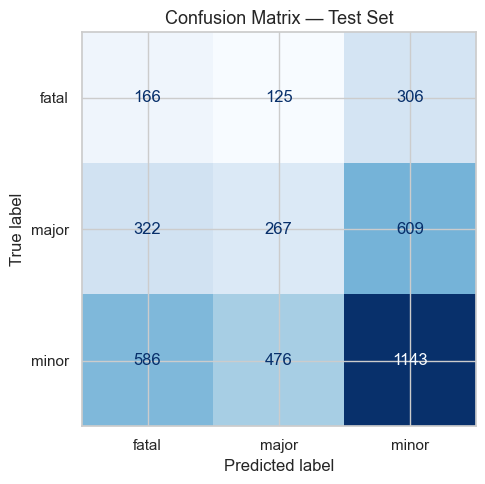

In [19]:
y_pred = clf.predict(X_test)

print('─── Classification Report ──────────────────────────────────')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f'Balanced Accuracy : {bal_acc:.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

### 3.5 Feature Importance

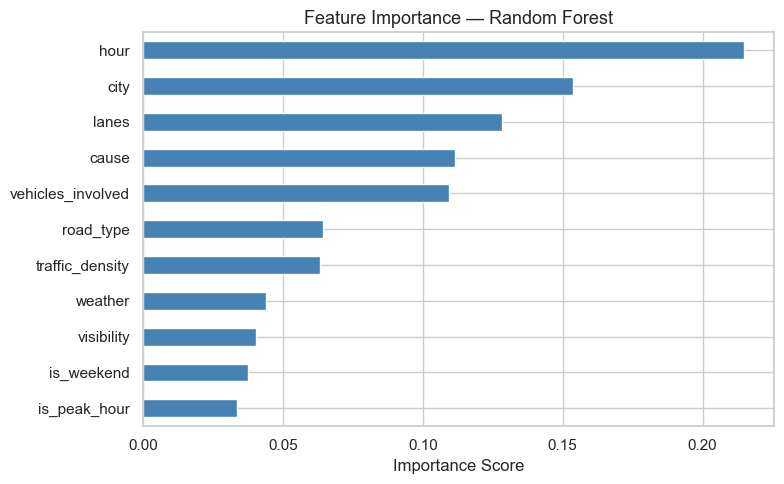

hour                 0.214791
city                 0.153752
lanes                0.128239
cause                0.111368
vehicles_involved    0.109349
road_type            0.064349
traffic_density      0.063099
weather              0.043992
visibility           0.040209
is_weekend           0.037381
is_peak_hour         0.033471
dtype: float64


In [20]:
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

<a id='widget'></a>
## 4. Interactive Widget – Severity Estimator

In [21]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ── Sorted unique values from the dataset ──────────────────────────────────
CITIES            = sorted(df['city'].unique().tolist())
WEATHERS          = sorted(df['weather'].unique().tolist())
ROAD_TYPES        = sorted(df['road_type'].unique().tolist())
TRAFFIC_DENSITIES = ['low', 'medium', 'high']
VISIBILITIES      = ['low', 'medium', 'high']
CAUSES            = sorted(df['cause'].unique().tolist())

style  = {'description_width': '160px'}
layout = widgets.Layout(width='380px')

# ── Widgets ─────────────────────────────────────────────────────────────────
w_city     = widgets.Dropdown(options=CITIES,            description='City:',             style=style, layout=layout)
w_weather  = widgets.Dropdown(options=WEATHERS,          description='Weather:',          style=style, layout=layout)
w_road     = widgets.Dropdown(options=ROAD_TYPES,        description='Road Type:',        style=style, layout=layout)
w_traffic  = widgets.Dropdown(options=TRAFFIC_DENSITIES, description='Traffic Density:',  style=style, layout=layout)
w_vis      = widgets.Dropdown(options=VISIBILITIES,      description='Visibility:',       style=style, layout=layout)
w_cause    = widgets.Dropdown(options=CAUSES,            description='Cause:',            style=style, layout=layout)
w_lanes    = widgets.IntSlider(value=3,    min=1,   max=8,   step=1,    description='Lanes:',             style=style, layout=layout)
w_vehicles = widgets.IntSlider(value=2,    min=1,   max=6,   step=1,    description='Vehicles Involved:',  style=style, layout=layout)
w_hour     = widgets.IntSlider(value=8,    min=0,   max=23,  step=1,    description='Hour (0-23):',        style=style, layout=layout)
w_btn      = widgets.Button(description='Predict Severity', button_style='primary',
                             layout=widgets.Layout(width='200px', height='36px'))
out        = widgets.Output()

color_map = {'minor': '#4caf50', 'major': '#ff9800', 'fatal': '#f44336'}

def safe_encode(le, val):
    classes = list(le.classes_)
    return int(le.transform([val])[0]) if val in classes else 0

def on_predict(b):
    with out:
        clear_output(wait=True)
        hour_val = w_hour.value
        is_peak  = 1 if hour_val in list(range(8, 11)) + list(range(17, 20)) else 0

        input_data = pd.DataFrame([{
            'city'             : safe_encode(le_dict['city'],            w_city.value),
            'weather'          : safe_encode(le_dict['weather'],         w_weather.value),
            'road_type'        : safe_encode(le_dict['road_type'],       w_road.value),
            'traffic_density'  : safe_encode(le_dict['traffic_density'], w_traffic.value),
            'visibility'       : safe_encode(le_dict['visibility'],      w_vis.value),
            'lanes'            : w_lanes.value,
            'vehicles_involved': w_vehicles.value,
            'hour'             : hour_val,
            'is_peak_hour'     : is_peak,
            'is_weekend'       : 0,
            'cause'            : safe_encode(le_dict['cause'],           w_cause.value),
        }])

        pred_encoded = clf.predict(input_data)[0]
        pred_proba   = clf.predict_proba(input_data)[0]
        pred_label   = le_target.inverse_transform([pred_encoded])[0]
        badge_color  = color_map.get(pred_label, '#888')

        rows = []
        for cls, p in zip(le_target.classes_, pred_proba):
            bar_color = color_map.get(cls, '#ccc')
            bar_width = int(p * 200)
            pct       = round(p * 100, 1)
            rows.append(
                '<tr>'
                '<td style="padding:3px 10px;">' + cls + '</td>'
                '<td><div style="background:' + bar_color + ';width:' + str(bar_width) + 'px;'
                'height:14px;border-radius:3px;"></div></td>'
                '<td style="padding:3px 6px;">' + str(pct) + '%</td>'
                '</tr>'
            )
        prob_html = ''.join(rows)

        peak_str    = 'Yes' if is_peak else 'No'
        summary_str = (w_city.value + ', ' + w_weather.value + ', ' + w_road.value
                       + ', cause=' + w_cause.value
                       + ', traffic=' + w_traffic.value + ', vis=' + w_vis.value
                       + ', lanes=' + str(w_lanes.value)
                       + ', vehicles=' + str(w_vehicles.value)
                       + ', hour=' + str(hour_val))

        html_out = (
            '<div style="font-family:sans-serif;border:1px solid #ddd;border-radius:8px;padding:18px;max-width:480px;">'
            '<h3 style="margin-top:0;">Prediction Result</h3>'
            '<p>Predicted Severity: '
            '<span style="background:' + badge_color + ';color:#fff;padding:4px 14px;'
            'border-radius:20px;font-weight:bold;font-size:15px;">'
            + pred_label.upper() +
            '</span></p>'
            '<p style="margin-top:12px;margin-bottom:4px;"><strong>Class Probabilities:</strong></p>'
            '<table style="border-collapse:collapse;">' + prob_html + '</table>'
            '<hr style="margin-top:14px;border:none;border-top:1px solid #eee;"/>'
            '<p style="font-size:12px;color:#777;">Peak hour: ' + peak_str + ' &nbsp;|&nbsp; ' + summary_str + '</p>'
            '</div>'
        )
        display(HTML(html_out))

w_btn.on_click(on_predict)

col1 = widgets.VBox([w_city, w_weather, w_road, w_vis, w_cause])
col2 = widgets.VBox([w_traffic, w_lanes, w_vehicles, w_hour])
form = widgets.HBox([col1, col2])

title = widgets.HTML(
    '<h3 style="margin-bottom:8px;">&#x1F6A6; Accident Severity Estimator</h3>'
    '<p style="color:#666;font-size:13px;">Select conditions below and click <em>Predict Severity</em>.</p>'
)

display(widgets.VBox([title, form, w_btn, out]))